# Анализ лояльности пользователей Яндекс Афиши

## Шаг 1. Загрузка данных

На этом этапе я подключаюсь к базе данных PostgreSQL и выгружаю данные с помощью SQL-запроса в датафрейм pandas.

В запрос включены только заказы, сделанные с устройств типов `mobile` и `desktop`. Также из выборки исключены события категории `фильм`, так как они не входят в рамки текущего анализа. Для каждого пользователя дополнительно рассчитывается количество дней с момента предыдущей покупки.

In [1]:
# !pip install phik

In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import phik
from phik.report import plot_correlation_matrix
import seaborn as sns

In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

engine = create_engine(connection_string)

query = """
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
        p.created_dt_msk::date
        - LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk
        )
    ) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e ON p.event_id = e.event_id
INNER JOIN afisha.city AS c ON e.city_id = c.city_id
INNER JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
"""

df = pd.read_sql_query(query, con=engine)

display(df.head())
print(df.shape)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


(290611, 15)


### Промежуточный вывод

Данные успешно выгружены в датафрейм. В выборке содержится информация о пользователях, заказах, устройствах, выручке, количестве билетов, типах мероприятий, регионах и городах проведения событий.

Также на этапе выгрузки был рассчитан признак `days_since_prev`, который показывает интервал в днях между текущей и предыдущей покупкой пользователя. Далее необходимо изучить структуру данных, проверить типы столбцов, объём выборки и наличие пропусков.

---

**Задача 1.2:** Изучим общую информацию о выгруженных данных. Оценим корректность выгрузки и объём полученных данных.

---

In [4]:
# Смотрим первые строки
display(df.head(10))

# Размер датафрейма
print('Размер датафрейма:', df.shape)

# Общая информация по таблице
df.info()

# Пропуски
display(df.isna().sum().sort_values(ascending=False))

# Числовые признаки
display(df.describe())

# Категориальные признаки
display(df.describe(include='object'))

# Проверим дубликаты строк
print('Количество полных дубликатов:', df.duplicated().sum())

# При желании можно отдельно проверить дубликаты заказов
print('Количество дубликатов order_id:', df['order_id'].duplicated().sum())

# Посмотрим диапазон дат
print('Минимальная дата заказа:', df['order_dt'].min())
print('Максимальная дата заказа:', df['order_dt'].max())

# Уникальные значения в ключевых категориальных столбцах
for col in ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 'city_name']:
    print(f'\nСтолбец: {col}')
    print('Количество уникальных значений:', df[col].nunique())
    print(df[col].dropna().unique()[:10])

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


Размер датафрейма: (290611, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name

days_since_prev          21933
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


,user_id,device_type_canonical,currency_code,event_name,event_type_main,service_name,region_name,city_name
count,290611,290611,290611,290611,290611,290611,290611,290611
unique,21933,2,2,15248,7,36,81,352
top,0beb8fc0c0a9ce1,mobile,rub,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Билеты без проблем,Каменевский регион,Глиногорск
freq,10251,232490,285542,3953,115276,63519,91058,89446


Количество полных дубликатов: 0
Количество дубликатов order_id: 0
Минимальная дата заказа: 2024-06-01 00:00:00
Максимальная дата заказа: 2024-10-31 00:00:00

Столбец: device_type_canonical
Количество уникальных значений: 2
['mobile' 'desktop']

Столбец: currency_code
Количество уникальных значений: 2
['rub' 'kzt']

Столбец: event_type_main
Количество уникальных значений: 7
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']

Столбец: service_name
Количество уникальных значений: 36
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры']

Столбец: region_name
Количество уникальных значений: 81
['Каменевский регион' 'Североярская область' 'Озернинский край'
 'Лугоградская область' 'Поленовский край' 'Широковская область'
 'Медовская область' 'Златопольский округ' 'Малиновоярский округ'
 'Яблоневская область']

Столбец: city_name
Количество уникальных значений: 352
['Глиногорск' 'Озёрск

In [5]:
print(df.columns.tolist())

print(df['device_type_canonical'].value_counts(dropna=False))
print(df['event_type_main'].value_counts(dropna=False).head(20))
print(df['currency_code'].value_counts(dropna=False))

['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'event_name', 'event_type_main', 'service_name', 'region_name', 'city_name']
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64
rub    285542
kzt      5069
Name: currency_code, dtype: int64


### Промежуточный вывод

Выгруженные данные содержат 290 611 строк и 15 столбцов. Период наблюдения — с 1 июня по 31 октября 2024 года. В датафрейме представлены все основные признаки, необходимые для анализа поведения пользователей: идентификаторы пользователей и заказов, дата и время заказа, валюта, выручка, количество билетов, тип мероприятия, билетный оператор, регион и город.

Выгрузка выглядит корректной: полных дубликатов и дубликатов по `order_id` не обнаружено, в столбце `device_type_canonical` присутствуют только категории `mobile` и `desktop`, категория `фильм` отсутствует, что соответствует условиям выгрузки.

Пропуски обнаружены только в столбце `days_since_prev` (21 933 значения), что ожидаемо для первых заказов пользователей. Типы данных в целом заданы корректно: столбцы с датой и временем уже имеют формат datetime, числовые признаки — числовые типы.

На этапе предобработки потребуется:
- привести выручку к единой валюте (рублям);
- проверить отрицательные значения и выбросы в `revenue`;
- изучить распределение `tickets_count` и возможные аномально крупные заказы;
- при необходимости оптимизировать типы данных и нормализовать категориальные признаки.

---

###  2. Предобработка данных

Выполним все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

---


In [6]:
# загружаем таблицу с курсом тенге
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# посмотрим на первые строки
display(tenge_rate.head())
tenge_rate.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [7]:
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])
df['order_dt'] = pd.to_datetime(df['order_dt'])

# оставим только нужные столбцы из таблицы курсов
tenge_rate = tenge_rate[['data', 'nominal', 'curs', 'cdx']]

# объединяем основную таблицу с курсами по дате заказа
df = df.merge(
    tenge_rate,
    left_on='order_dt',
    right_on='data',
    how='left'
)

# создаём столбец с выручкой в рублях
df['revenue_rub'] = np.where(
    df['currency_code'] == 'rub',
    df['revenue'],
    df['revenue'] * df['curs'] / df['nominal']
)

# проверим результат
display(df[['order_dt', 'currency_code', 'revenue', 'nominal', 'curs', 'revenue_rub']].head(10))

# проверка пропусков в новом столбце
print('Пропусков в revenue_rub:', df['revenue_rub'].isna().sum())

,order_dt,currency_code,revenue,nominal,curs,revenue_rub
0,2024-08-20,rub,1521.94,100,18.6972,1521.94
1,2024-07-23,rub,289.45,100,18.3419,289.45
2,2024-10-06,rub,1258.57,100,19.6475,1258.57
3,2024-07-13,rub,8.49,100,18.5010,8.49
4,2024-10-04,rub,1390.41,100,19.6648,1390.41
5,2024-10-23,rub,902.74,100,20.0531,902.74
6,2024-08-15,rub,917.83,100,18.7730,917.83
7,2024-09-29,rub,47.78,100,19.3741,47.78
8,2024-10-15,rub,74.84,100,19.7185,74.84
9,2024-06-20,rub,1421.91,100,18.0419,1421.91


Пропусков в revenue_rub: 0


In [8]:
print(df['currency_code'].value_counts())

display(df.groupby('currency_code')[['revenue', 'revenue_rub']].agg(['min', 'median', 'mean', 'max']))

rub    285542
kzt      5069
Name: currency_code, dtype: int64


revenue                                 revenue_rub              \
                  min   median         mean       max         min      median   
currency_code                                                                   
kzt              0.00  3698.83  4995.206767  26425.86        0.00  734.654217   
rub            -90.76   346.63   548.013929  81174.54      -90.76  346.630000   

                                         
                     mean           max  
currency_code                            
kzt            981.325159   5256.843478  
rub            548.013929  81174.540000

### Промежуточный вывод

Выручка по всем заказам успешно приведена к единой валюте — российскому рублю. Для этого данные по заказам были объединены с таблицей курсов тенге по дате заказа, после чего был создан новый столбец `revenue_rub`.

Пропусков в новом столбце не обнаружено, значит курс был корректно сопоставлен для всех заказов. Для заказов в рублях значения выручки сохранились без изменений, а для заказов в тенге выручка была пересчитана по актуальному курсу на дату покупки.

На следующем этапе необходимо проверить данные на пропуски, изучить типы столбцов, исследовать категориальные признаки и отдельно проанализировать распределение `revenue_rub` и `tickets_count`, включая поиск аномалий и выбросов.

---

**Задача 2.2:**

- Проверим данные на пропущенные значения. 
- Преобразуем типы данных в некоторых столбцах, если это необходимо. 
- Изучим значения в ключевых столбцах. Обработаем ошибки.

---

In [9]:
# проверка пропусков
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

missing_share = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_share)

days_since_prev          21933
user_id                      0
event_type_main              0
cdx                          0
curs                         0
nominal                      0
data                         0
city_name                    0
region_name                  0
service_name                 0
event_name                   0
device_type_canonical        0
event_id                     0
tickets_count                0
revenue                      0
currency_code                0
order_ts                     0
order_dt                     0
order_id                     0
revenue_rub                  0
dtype: int64

days_since_prev          7.547202
user_id                  0.000000
event_type_main          0.000000
cdx                      0.000000
curs                     0.000000
nominal                  0.000000
data                     0.000000
city_name                0.000000
region_name              0.000000
service_name             0.000000
event_name               0.000000
device_type_canonical    0.000000
event_id                 0.000000
tickets_count            0.000000
revenue                  0.000000
currency_code            0.000000
order_ts                 0.000000
order_dt                 0.000000
order_id                 0.000000
revenue_rub              0.000000
dtype: float64

In [10]:
# проверим типы до преобразования
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [11]:
# даты
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

# целочисленные столбцы
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

# вещественные столбцы
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

# проверим типы после преобразования
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [12]:
display(df[['revenue', 'revenue_rub', 'tickets_count', 'days_since_prev']].describe())

print('Отрицательная revenue:', (df['revenue'] < 0).sum())
print('Отрицательная revenue_rub:', (df['revenue_rub'] < 0).sum())
print('Нулевая revenue_rub:', (df['revenue_rub'] == 0).sum())
print('tickets_count <= 0:', (df['tickets_count'] <= 0).sum())
print('days_since_prev < 0:', (df['days_since_prev'] < 0).sum())

,revenue,revenue_rub,tickets_count,days_since_prev
count,290611.000000,290611.000000,290611.000000,268678.000000
mean,625.584412,555.571960,2.754311,3.222381
std,1227.693115,875.498169,1.170620,11.350510
min,-90.760002,-90.760002,1.000000,0.000000
25%,116.849998,113.970001,2.000000,0.000000
50%,356.010010,351.140015,3.000000,0.000000
75%,810.130005,802.049988,4.000000,1.000000
max,81174.539062,81174.539062,57.000000,148.000000


Отрицательная revenue: 381
Отрицательная revenue_rub: 381
Нулевая revenue_rub: 5526
tickets_count <= 0: 0
days_since_prev < 0: 0


In [13]:
cat_check_cols = [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name'
]

for col in cat_check_cols:
    print(f'\nСтолбец: {col}')
    print(df[col].value_counts(dropna=False).head(15))


Столбец: device_type_canonical
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Столбец: currency_code
rub    285542
kzt      5069
Name: currency_code, dtype: int64

Столбец: event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Столбец: service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Name: service_name, dtype: int64

Столбец: region_name
Каменевский регион         91058
Североярская облас

In [14]:
possible_missing = ['', ' ', 'unknown', 'unk', 'none', 'null', 'nan', 'не указано', 'нет данных', 'нет']

for col in cat_check_cols:
    values_lower = df[col].astype(str).str.lower().str.strip()
    found = values_lower.isin(possible_missing).sum()
    print(f'{col}: найдено подозрительных значений = {found}')

device_type_canonical: найдено подозрительных значений = 0
currency_code: найдено подозрительных значений = 0
event_type_main: найдено подозрительных значений = 0
service_name: найдено подозрительных значений = 0
region_name: найдено подозрительных значений = 0
city_name: найдено подозрительных значений = 0


In [15]:
#уберем ненужные столбцы
cols_to_drop = [
    'data_x', 'nominal_x', 'curs_x', 'cdx_x',
    'data_y', 'nominal_y', 'curs_y', 'cdx_y',
    'data', 'nominal', 'curs', 'cdx'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

- revenue_rub имеет сильную правостороннюю асимметрию и длинный хвост;
- среднее заметно выше медианы, значит есть дорогие заказы, которые тянут среднее вверх;
- максимум сильно отличается от 75-го перцентиля, значит выбросы есть;
- tickets_count в основном сосредоточен около 2–4 билетов, но максимум 57 выглядит как аномально крупный заказ.

In [16]:
revenue_99 = df['revenue_rub'].quantile(0.99)
print('99-й перцентиль revenue_rub:', revenue_99)

rows_before = len(df)

df_filtered = df[df['revenue_rub'] <= revenue_99].copy()

rows_after = len(df_filtered)

print('Строк до фильтрации:', rows_before)
print('Строк после фильтрации:', rows_after)
print('Удалено строк:', rows_before - rows_after)
print('Доля удалённых строк, %:', round((rows_before - rows_after) / rows_before * 100, 2))

99-й перцентиль revenue_rub: 2628.421630859375
Строк до фильтрации: 290611
Строк после фильтрации: 287786
Удалено строк: 2825
Доля удалённых строк, %: 0.97


In [17]:
df = df_filtered.copy()

### Промежуточный вывод

На этапе предобработки было подтверждено, что пропуски присутствуют только в столбце `days_since_prev`, что соответствует логике данных: для первого заказа пользователя интервал до предыдущей покупки отсутствует.

Типы данных были оптимизированы: столбцы с датой и временем сохранены в формате `datetime`, а числовые — в более компактные форматы. Это позволило уменьшить объём используемой памяти.

Проверка категориальных признаков показала, что скрытых пропусков и некорректных значений не обнаружено. В числовых данных были выявлены особенности: отрицательные и нулевые значения в `revenue_rub`, а также длинный правый хвост распределения выручки. В столбце `tickets_count` большинство значений сосредоточено в диапазоне от 1 до 4 билетов, хотя встречаются и крупные заказы.

После объединения с таблицей курсов были удалены технические столбцы, использованные только для пересчёта валют. Новый столбец `revenue_rub` содержит выручку заказа, приведённую к единой валюте — российскому рублю.

Для снижения влияния выбросов данные по `revenue_rub` были отфильтрованы по 99-му перцентилю. Порог составил 2628.42 руб., при этом было удалено 2825 строк, или 0.97% наблюдений. Таким образом, очищенный датасет сохраняет почти весь объём исходной выборки и подходит для дальнейшего анализа.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. 

---

**Задача 3.1.** Построим профиль пользователя — для каждого пользователя найдем:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

---


In [18]:
# сортируем по пользователю и времени
df = df.sort_values(['user_id', 'order_ts']).copy()

# берём первый заказ каждого пользователя
first_orders = df.drop_duplicates(subset='user_id', keep='first')

# агрегируем основные метрики
user_profile = (
    df.groupby('user_id')
      .agg(
          first_order_dt=('order_dt', 'min'),
          last_order_dt=('order_dt', 'max'),
          total_orders=('order_id', 'count'),
          avg_revenue_rub=('revenue_rub', 'mean'),
          avg_tickets_count=('tickets_count', 'mean'),
          avg_days_between=('days_since_prev', 'mean')
      )
      .reset_index()
)

# добавляем признаки первого заказа
user_profile = user_profile.merge(
    first_orders[
        [
            'user_id',
            'device_type_canonical',
            'region_name',
            'service_name',
            'event_type_main'
        ]
    ],
    on='user_id',
    how='left'
)

# переименуем
user_profile = user_profile.rename(columns={
    'device_type_canonical': 'first_device_type',
    'region_name': 'first_region_name',
    'service_name': 'first_service_name',
    'event_type_main': 'first_event_type_main'
})

# бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype('int8')
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype('int8')

# округление
user_profile['avg_revenue_rub'] = user_profile['avg_revenue_rub'].round(2)
user_profile['avg_tickets_count'] = user_profile['avg_tickets_count'].round(2)
user_profile['avg_days_between'] = user_profile['avg_days_between'].round(2)

# проверка
display(user_profile.head())
print(user_profile.shape)

,user_id,first_order_dt,last_order_dt,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,first_device_type,first_region_name,first_service_name,first_event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.00,NaN,mobile,Каменевский регион,Край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.00,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,767.210022,2.67,51.0,mobile,Североярская область,Лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.00,NaN,desktop,Каменевский регион,Край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310001,1.50,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0


(21854, 13)


### Промежуточный вывод

Для каждого пользователя был построен агрегированный профиль, объединяющий характеристики первого заказа и количественные показатели поведения. В результате получен датасет, где одна строка соответствует одному пользователю.

Профиль включает как признаки первого взаимодействия с платформой, так и агрегированные метрики по всем заказам пользователя. Дополнительно были созданы бинарные признаки, отражающие факт повторной покупки и более высокой активности пользователя.

Полученный датасет можно использовать для дальнейшего исследовательского анализа: изучения факторов возврата, сегментации пользователей и поиска признаков, связанных с количеством заказов.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучим статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оценим данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

In [19]:
# общее число пользователей
users_count = user_profile['user_id'].nunique()

# средняя выручка с одного заказа
avg_order_revenue = user_profile['avg_revenue_rub'].mean()

# доля пользователей с 2+ заказами
share_two = user_profile['is_two'].mean()

# доля пользователей с 5+ заказами
share_five = user_profile['is_five'].mean()

print('Общее число пользователей:', users_count)
print('Средняя выручка с одного заказа:', round(avg_order_revenue, 2))
print('Доля пользователей с 2 и более заказами:', round(share_two * 100, 2), '%')
print('Доля пользователей с 5 и более заказами:', round(share_five * 100, 2), '%')

Общее число пользователей: 21854
Средняя выручка с одного заказа: 544.4
Доля пользователей с 2 и более заказами: 61.71 %
Доля пользователей с 5 и более заказами: 29.01 %


In [20]:
display(
    user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

,total_orders,avg_tickets_count,avg_days_between
count,21854.000000,21854.000000,13521.000000
mean,13.168573,2.743136,15.836092
std,121.674800,0.913090,22.297935
min,1.000000,1.000000,0.000000
1%,1.000000,1.000000,0.000000
5%,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.400000
95%,31.350000,4.000000,61.500000


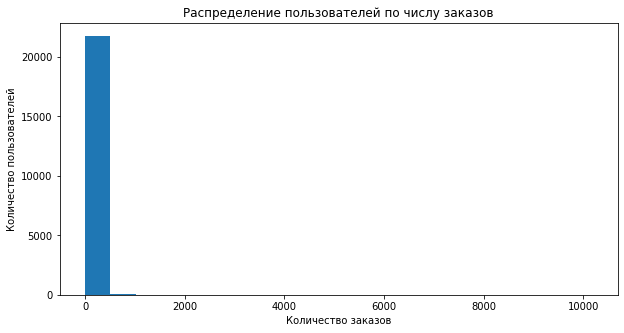

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['total_orders'], bins=20)
plt.title('Распределение пользователей по числу заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.show()

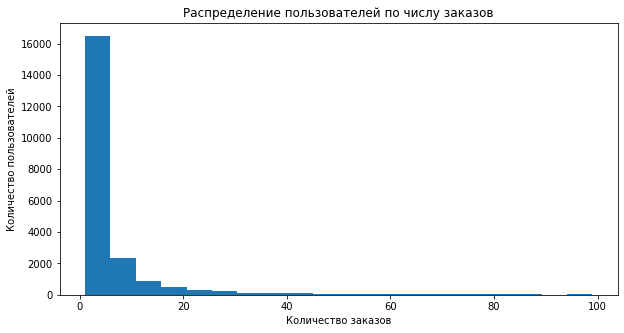

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile[user_profile['total_orders'] < 100]['total_orders'], bins=20)
plt.title('Распределение пользователей по числу заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.show()

In [23]:
display(user_profile['total_orders'].describe(percentiles=[0.95, 0.99]))

orders_95 = user_profile['total_orders'].quantile(0.95)
orders_99 = user_profile['total_orders'].quantile(0.99)

print('95-й перцентиль total_orders:', orders_95)
print('99-й перцентиль total_orders:', orders_99)

print('Пользователей выше 95-го перцентиля:', (user_profile['total_orders'] > orders_95).sum())
print('Пользователей выше 99-го перцентиля:', (user_profile['total_orders'] > orders_99).sum())

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
50%          2.000000
95%         31.350000
99%        152.000000
max      10181.000000
Name: total_orders, dtype: float64

95-й перцентиль total_orders: 31.349999999998545
99-й перцентиль total_orders: 152.0
Пользователей выше 95-го перцентиля: 1093
Пользователей выше 99-го перцентиля: 216


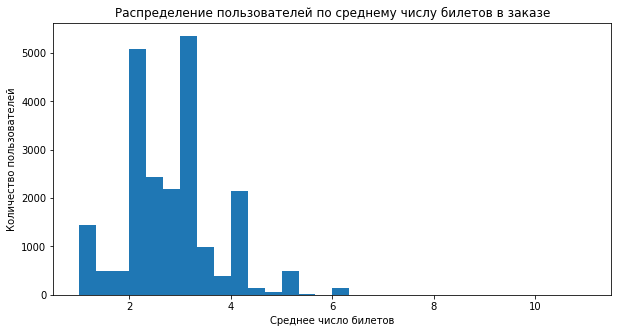

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_tickets_count'], bins=30)
plt.title('Распределение пользователей по среднему числу билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.ylabel('Количество пользователей')
plt.show()

In [25]:
display(user_profile['avg_tickets_count'].describe(percentiles=[0.95, 0.99]))

tickets_95 = user_profile['avg_tickets_count'].quantile(0.95)
tickets_99 = user_profile['avg_tickets_count'].quantile(0.99)

print('95-й перцентиль avg_tickets_count:', tickets_95)
print('99-й перцентиль avg_tickets_count:', tickets_99)

print('Пользователей выше 95-го перцентиля:', (user_profile['avg_tickets_count'] > tickets_95).sum())
print('Пользователей выше 99-го перцентиля:', (user_profile['avg_tickets_count'] > tickets_99).sum())

count    21854.000000
mean         2.743136
std          0.913090
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64

95-й перцентиль avg_tickets_count: 4.0
99-й перцентиль avg_tickets_count: 5.0
Пользователей выше 95-го перцентиля: 968
Пользователей выше 99-го перцентиля: 194


In [26]:
# самые активные пользователи
display(
    user_profile.sort_values('total_orders', ascending=False)[
        ['user_id', 'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
    ].head(10)
)

# пользователи с самым большим средним числом билетов
display(
    user_profile.sort_values('avg_tickets_count', ascending=False)[
        ['user_id', 'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
    ].head(10)
)

,user_id,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between
981,0beb8fc0c0a9ce1,10181,505.149994,2.86,0.01
2054,18e9aead0a393e7,4351,494.829987,2.79,0.03
11073,8187dac4be757a0,4021,537.419983,2.75,0.04
5414,3ee7dc2e115847f,3791,536.950012,2.76,0.04
10810,7eb4fc207ecc10f,3710,542.630005,2.96,0.04
2330,1c2a2133e1df1b4,3503,541.559998,2.67,0.04
6776,4ec8f6429431987,3375,549.789978,2.73,0.04
14765,ad2dc32364ed948,3249,447.730011,2.94,0.05
15502,b54dd0cd81121fc,3138,481.609985,2.81,0.05
17634,cdbc02c6ad8087a,3036,466.970001,2.76,0.05


,user_id,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between
8840,6713518780e7e81,1,116.239998,11.00,NaN
2360,1c8a65abba03a4c,1,1253.859985,10.00,NaN
6410,4a815181dcec5f0,1,878.510010,10.00,NaN
1400,1118cc4889189db,2,677.099976,9.00,0.0
10113,76694a971889caa,3,647.140015,8.67,7.0
19825,e7c7503a958a4c3,1,666.030029,8.00,NaN
2843,21dd23dfd8b40cc,1,582.780029,7.00,NaN
1402,112134e55aba922,2,907.539978,7.00,0.0
8978,68b0fbd811fe024,1,907.539978,7.00,NaN
4702,37002ffdb00ca63,2,891.409973,7.00,31.0


### Промежуточный вывод

На основе пользовательских профилей было установлено, что в выборке содержится 21 854 пользователя. Средняя выручка с одного заказа составляет 544.4 руб. Доля пользователей, совершивших 2 и более заказа, равна 61.71%, а доля пользователей, совершивших 5 и более заказов, — 29.01%.

Распределение числа заказов сильно скошено вправо. У половины пользователей не более 2 заказов, у 75% — не более 5 заказов, однако в данных присутствует небольшая группа очень активных пользователей с экстремально большим числом заказов. Максимальное значение составляет 10 181 заказ, а 99-й перцентиль — 152 заказа. Это говорит о наличии выбросов или, по крайней мере, крайне редких наблюдений, которые могут заметно влиять на средние показатели.

Распределение среднего количества билетов в заказе выглядит значительно стабильнее. Основная масса пользователей покупает в среднем от 2 до 4 билетов, 99-й перцентиль составляет 5 билетов, а максимальное значение равно 11. Такие значения выглядят редкими, но допустимыми, поэтому дополнительная фильтрация по этому признаку не требуется.

Таким образом, выборка выглядит репрезентативной и достаточной по объёму для дальнейшего анализа. Пользователей с экстремально большим числом заказов решено не удалять из датасета, однако их наличие необходимо учитывать при интерпретации результатов и построении визуализаций.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуем признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

---


In [27]:
def segment_distribution(df, column):
    segment_df = (
        df.groupby(column)
        .agg(users_count=('user_id', 'count'))
        .reset_index()
        .sort_values('users_count', ascending=False)
    )
    
    segment_df['users_share'] = (
        segment_df['users_count'] / segment_df['users_count'].sum() * 100
    ).round(2)
    
    return segment_df

1. По типу первого мероприятия

In [28]:
event_type_dist = segment_distribution(user_profile, 'first_event_type_main')
display(event_type_dist)

,first_event_type_main,users_count,users_share
2,концерты,9643,44.12
1,другое,5490,25.12
5,театр,4289,19.63
4,стендап,1118,5.12
3,спорт,801,3.67
0,выставки,418,1.91
6,ёлки,95,0.43


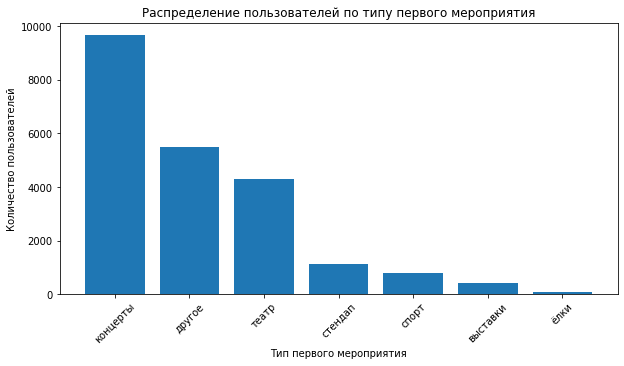

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(event_type_dist['first_event_type_main'], event_type_dist['users_count'])
plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

2. По типу устройства первого заказа

In [30]:
device_dist = segment_distribution(user_profile, 'first_device_type')
display(device_dist)

,first_device_type,users_count,users_share
1,mobile,18108,82.86
0,desktop,3746,17.14


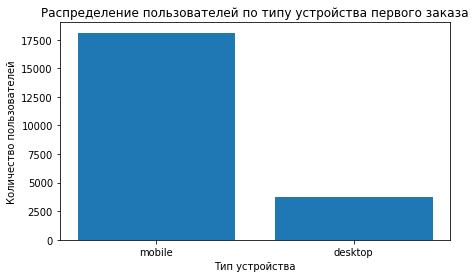

In [31]:
plt.figure(figsize=(7, 4))
plt.bar(device_dist['first_device_type'], device_dist['users_count'])
plt.title('Распределение пользователей по типу устройства первого заказа')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.show()

3. По региону первого заказа

In [32]:
region_dist = segment_distribution(user_profile, 'first_region_name')
display(region_dist.head(10))

,first_region_name,users_count,users_share
23,Каменевский регион,7159,32.76
60,Североярская область,3799,17.38
77,Широковская область,1237,5.66
45,Озернинский край,678,3.10
41,Малиновоярский округ,529,2.42
76,Шанырский регион,503,2.30
74,Травяная область,493,2.26
57,Светополянский округ,464,2.12
52,Речиновская область,446,2.04
78,Яблоневская область,416,1.90


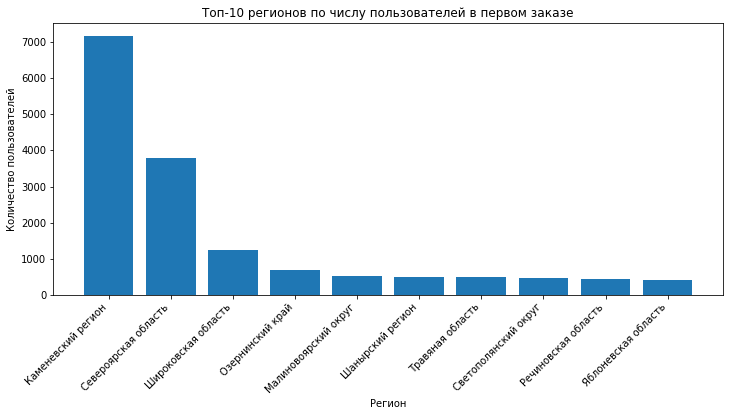

In [33]:
top_regions = region_dist.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_regions['first_region_name'], top_regions['users_count'])
plt.title('Топ-10 регионов по числу пользователей в первом заказе')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45, ha='right')
plt.show()

4. По билетному оператору первого заказа

In [34]:
service_dist = segment_distribution(user_profile, 'first_service_name')
display(service_dist.head(10))

,first_service_name,users_count,users_share
3,Билеты без проблем,5223,23.90
22,Мой билет,2992,13.69
19,Лови билет!,2848,13.03
4,Билеты в руки,2594,11.87
23,Облачко,2194,10.04
7,Весь в билетах,1304,5.97
20,Лучшие билеты,1188,5.44
24,Прачечная,588,2.69
17,Край билетов,459,2.10
12,Дом культуры,358,1.64


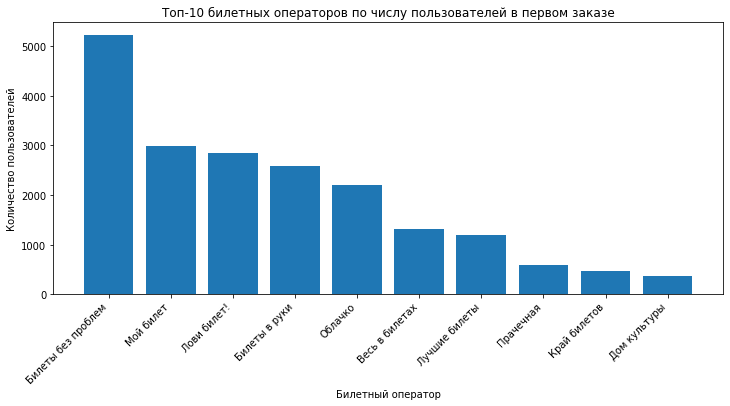

In [35]:
top_services = service_dist.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_services['first_service_name'], top_services['users_count'])
plt.title('Топ-10 билетных операторов по числу пользователей в первом заказе')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45, ha='right')
plt.show()

### Промежуточный вывод

Распределение пользователей по признакам первого заказа является неравномерным. В данных наблюдаются выраженные точки входа — сегменты, через которые на платформу приходит заметно больше пользователей, чем через остальные.

По типу первого мероприятия основная доля пользователей пришла через категорию `концерты` — 9 643 пользователя, или 44.12% выборки. Далее идут категории `другое` (25.12%) и `театр` (19.63%). Остальные типы мероприятий заметно уступают им по числу пользователей. Это означает, что именно концерты являются главным каналом первого входа пользователей на платформу.

По типу устройства первый заказ в большинстве случаев совершается с мобильных устройств: на сегмент `mobile` приходится 82.86% пользователей, тогда как на `desktop` — только 17.14%. Таким образом, мобильные устройства являются основным входным каналом.

По региону первого заказа распределение также сконцентрировано. На `Каменевский регион` приходится 32.76% пользователей, а на `Североярскую область` — 17.38%. Уже два региона формируют около половины всей выборки. Остальные регионы представлены значительно слабее.

По билетным операторам также есть выраженная концентрация. Лидером является `Билеты без проблем` с долей 23.90%, далее идут `Мой билет` (13.69%), `Лови билет!` (13.03%), `Билеты в руки` (11.87%) и `Облачко` (10.04%). Несколько крупнейших партнёров аккумулируют значительную часть первого пользовательского потока.

Таким образом, пользователей нельзя считать равномерно распределёнными по сегментам. В выборке явно присутствуют основные точки входа: концерты как тип первого мероприятия, мобильные устройства как основной канал покупки, а также ограниченный набор регионов и билетных операторов, через которые приходит наибольшая часть пользователей.

---

**Задача 4.1.2.** Проанализируем возвраты пользователей:

---


In [36]:
def segment_return_rate(df, column):
    result = (
        df.groupby(column)
        .agg(
            users_count=('user_id', 'count'),
            return_rate=('is_two', 'mean')
        )
        .reset_index()
        .sort_values('users_count', ascending=False)
    )
    
    result['return_rate'] = (result['return_rate'] * 100).round(2)
    result['users_share'] = (result['users_count'] / result['users_count'].sum() * 100).round(2)
    
    return result

In [37]:
event_returns = segment_return_rate(user_profile, 'first_event_type_main')
device_returns = segment_return_rate(user_profile, 'first_device_type')
region_returns = segment_return_rate(user_profile, 'first_region_name')
service_returns = segment_return_rate(user_profile, 'first_service_name')

display(event_returns)
display(device_returns)
display(region_returns.head(10))
display(service_returns.head(10))

,first_event_type_main,users_count,return_rate,users_share
2,концерты,9643,62.16,44.12
1,другое,5490,60.09,25.12
5,театр,4289,63.81,19.63
4,стендап,1118,61.18,5.12
3,спорт,801,56.18,3.67
0,выставки,418,64.35,1.91
6,ёлки,95,55.79,0.43


,first_device_type,users_count,return_rate,users_share
1,mobile,18108,61.21,82.86
0,desktop,3746,64.12,17.14


,first_region_name,users_count,return_rate,users_share
23,Каменевский регион,7159,62.79,32.76
60,Североярская область,3799,64.12,17.38
77,Широковская область,1237,64.92,5.66
45,Озернинский край,678,55.46,3.10
41,Малиновоярский округ,529,56.33,2.42
76,Шанырский регион,503,67.40,2.30
74,Травяная область,493,61.87,2.26
57,Светополянский округ,464,66.16,2.12
52,Речиновская область,446,63.90,2.04
78,Яблоневская область,416,59.86,1.90


,first_service_name,users_count,return_rate,users_share
3,Билеты без проблем,5223,60.69,23.90
22,Мой билет,2992,61.16,13.69
19,Лови билет!,2848,61.45,13.03
4,Билеты в руки,2594,63.22,11.87
23,Облачко,2194,61.58,10.04
7,Весь в билетах,1304,63.42,5.97
20,Лучшие билеты,1188,61.36,5.44
24,Прачечная,588,62.93,2.69
17,Край билетов,459,65.58,2.10
12,Дом культуры,358,64.80,1.64


In [38]:
overall_return_rate = user_profile['is_two'].mean() * 100
print(round(overall_return_rate, 2))

61.71


1. По типу первого мероприятия

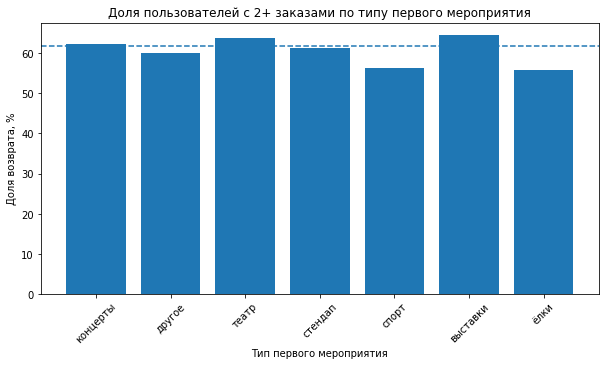

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(event_returns['first_event_type_main'], event_returns['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Доля возврата, %')
plt.xticks(rotation=45)
plt.show()

2. По типу устройства

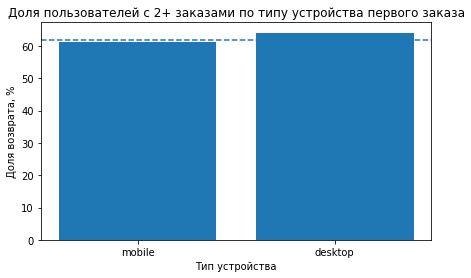

In [40]:
plt.figure(figsize=(7, 4))
plt.bar(device_returns['first_device_type'], device_returns['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по типу устройства первого заказа')
plt.xlabel('Тип устройства')
plt.ylabel('Доля возврата, %')
plt.show()

3. Топ-10 регионов по числу пользователей

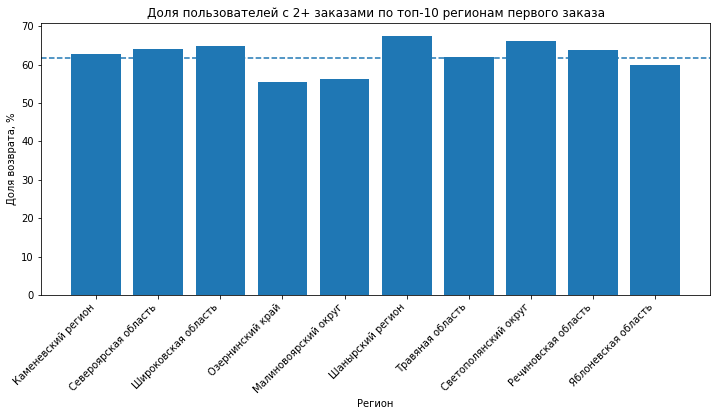

In [41]:
top_regions_returns = region_returns.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_regions_returns['first_region_name'], top_regions_returns['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по топ-10 регионам первого заказа')
plt.xlabel('Регион')
plt.ylabel('Доля возврата, %')
plt.xticks(rotation=45, ha='right')
plt.show()

4. Топ-10 операторов по числу пользователей

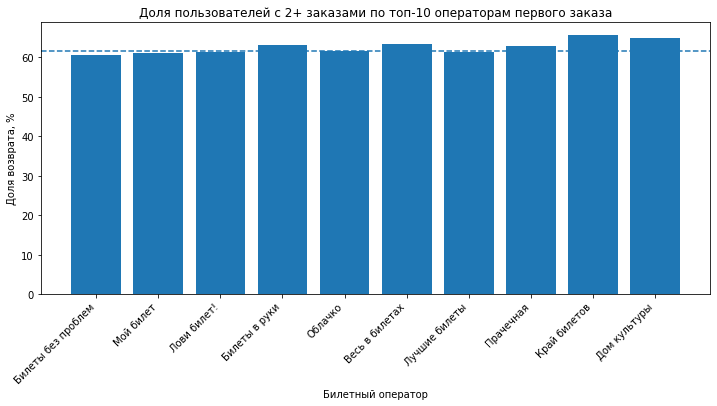

In [42]:
top_services_returns = service_returns.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_services_returns['first_service_name'], top_services_returns['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по топ-10 операторам первого заказа')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля возврата, %')
plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
# сегменты выше среднего по выборке
event_success = event_returns[event_returns['return_rate'] > overall_return_rate]
device_success = device_returns[device_returns['return_rate'] > overall_return_rate]
region_success = region_returns[region_returns['return_rate'] > overall_return_rate]
service_success = service_returns[service_returns['return_rate'] > overall_return_rate]

display(event_success)
display(device_success)
display(region_success.head(10))
display(service_success.head(10))

,first_event_type_main,users_count,return_rate,users_share
2,концерты,9643,62.16,44.12
5,театр,4289,63.81,19.63
0,выставки,418,64.35,1.91


,first_device_type,users_count,return_rate,users_share
0,desktop,3746,64.12,17.14


,first_region_name,users_count,return_rate,users_share
23,Каменевский регион,7159,62.79,32.76
60,Североярская область,3799,64.12,17.38
77,Широковская область,1237,64.92,5.66
76,Шанырский регион,503,67.40,2.30
74,Травяная область,493,61.87,2.26
57,Светополянский округ,464,66.16,2.12
52,Речиновская область,446,63.90,2.04
11,Горицветская область,255,67.84,1.17
18,Заречная область,214,66.36,0.98
54,Речицкий регион,197,65.99,0.90


,first_service_name,users_count,return_rate,users_share
4,Билеты в руки,2594,63.22,11.87
7,Весь в билетах,1304,63.42,5.97
24,Прачечная,588,62.93,2.69
17,Край билетов,459,65.58,2.10
12,Дом культуры,358,64.80,1.64
21,Мир касс,211,64.93,0.97
1,Show_ticket,163,66.26,0.75
10,Выступления.ру,96,62.50,0.44
8,Восьмёрка,86,68.60,0.39
6,Быстрый кассир,61,85.25,0.28


### Промежуточный вывод

Средняя доля пользователей, совершивших 2 и более заказа, по всей выборке составляет 61.71%. Сравнение сегментов первого заказа с этим уровнем показывает, что вероятность возврата действительно различается в зависимости от характеристик первого взаимодействия с платформой.

По типу первого мероприятия чаще среднего возвращаются пользователи, чей первый заказ был связан с `театром` (63.81%), `концертами` (62.16%) и `выставками` (64.35%). При этом сегмент `выставки` очень мал по объёму (418 пользователей), поэтому его результат менее устойчив. Наиболее надёжными успешными точками входа здесь выглядят `концерты` и `театр`, поскольку они одновременно крупные по числу пользователей и показывают возврат выше среднего. Хуже среднего возвращаются пользователи, пришедшие через `спорт` (56.18%), `ёлки` (55.79%) и `другое` (60.09%).

По типу устройства более высокий возврат показывают пользователи, совершившие первый заказ с `desktop` — 64.12% против 61.21% у `mobile`. Несмотря на то что основной объём аудитории приходит с мобильных устройств, именно десктопный сегмент демонстрирует более высокую вероятность повторного заказа.

По регионам среди крупнейших сегментов особенно выделяются `Шанырский регион` (67.40%), `Светополянский округ` (66.16%), `Широковская область` (64.92%), `Североярская область` (64.12%) и `Каменевский регион` (62.79%). Успешной точкой входа можно считать `Каменевский регион`, поскольку это крупнейший сегмент по числу пользователей и его доля возврата выше средней. В то же время `Озернинский край` (55.46%) и `Малиновоярский округ` (56.33%) показывают заметно более слабое удержание.

По билетным операторам среди наиболее крупных и устойчивых сегментов лучше среднего возвращаются пользователи, впервые купившие билеты через `Билеты в руки` (63.22%) и `Весь в билетах` (63.42%). Также высокий возврат показывают `Край билетов` (65.58%) и `Дом культуры` (64.80%), однако их сегменты значительно меньше. Наиболее заметный массовый оператор — `Билеты без проблем` — привлекает больше всего пользователей, но его доля возврата ниже средней (60.69%), поэтому его нельзя назвать успешной точкой входа с точки зрения удержания.

Таким образом, успешные точки входа в выборке действительно наблюдаются. Наиболее надёжными среди них можно считать:
- `концерты` и `театр` как тип первого мероприятия;
- `desktop` как тип устройства первого заказа;
- `Каменевский регион`, `Североярскую область` и `Широковскую область` среди крупных региональных сегментов;
- `Билеты в руки` и `Весь в билетах` среди крупных билетных операторов.

При этом сегменты с очень высокой долей возврата, но небольшим числом пользователей, например `Быстрый кассир` или `Восьмёрка`, стоит интерпретировать осторожно: такие результаты могут быть нестабильными из-за малого размера выборки.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверим продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

---

По данным:

* спорт — 56.18%
* концерты — 62.16%

Гипотеза 1 не подтвердилась. Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются реже пользователей, оформивших первый заказ на концерты. Доля пользователей с 2 и более заказами составляет 56.18% для сегмента `спорт` против 62.16% для сегмента `концерты`.

Следовательно, первый заказ на спортивное мероприятие не связан с более высокой вероятностью возврата по сравнению с концертами. Напротив, концерты выглядят более успешной точкой входа с точки зрения удержания пользователей.

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Смотрим на самые крупные регионы:

- Каменевский регион — 7159 пользователей, возврат 62.79%
- Североярская область — 3799 пользователей, возврат 64.12%
- Широковская область — 1237 пользователей, возврат 64.92%

Но среди менее крупных регионов есть и более высокие значения:

- Шанырский регион — 503 пользователя, возврат 67.40%
- Светополянский округ — 464 пользователя, возврат 66.16%

И наоборот, среди достаточно заметных сегментов есть более слабые:

- Озернинский край — 678 пользователей, возврат 55.46%
- Малиновоярский округ — 529 пользователей, возврат 56.33%

То есть прямой зависимости вида
“чем больше пользователей в регионе, тем выше возврат”
по данным не наблюдается.

Гипотеза 2 не подтвердилась в явном виде. Среди крупнейших регионов действительно есть сегменты с долей повторных заказов выше средней по выборке, например `Каменевский регион` (62.79%) и `Североярская область` (64.12%). Однако более высокие показатели возврата встречаются и в менее крупных регионах, таких как `Шанырский регион` (67.40%) и `Светополянский округ` (66.16%).

Кроме того, среди регионов с заметным числом пользователей есть сегменты с более низким удержанием, например `Озернинский край` (55.46%) и `Малиновоярский округ` (56.33%). Это означает, что высокая активность региона по числу пользователей сама по себе не гарантирует более высокой доли повторных заказов.

Следовательно, связь между размером регионального сегмента и вероятностью возврата не является однозначной. Для оценки успешности региона нужно учитывать не только объём аудитории, но и фактическую долю повторных покупок.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

---

**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

---


In [44]:
one_order = user_profile[user_profile['total_orders'] == 1]
returned_users = user_profile[user_profile['total_orders'] >= 2]

print('Пользователей с 1 заказом:', len(one_order))
print('Пользователей с 2+ заказами:', len(returned_users))

Пользователей с 1 заказом: 8368
Пользователей с 2+ заказами: 13486


In [45]:
display(one_order['avg_revenue_rub'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
display(returned_users['avg_revenue_rub'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

count    8368.000000
mean      545.295654
std       519.514099
min       -10.770000
5%         21.059999
25%       132.070000
50%       378.029999
75%       830.317520
95%      1577.800049
max      2628.419922
Name: avg_revenue_rub, dtype: float64

count    13486.000000
mean       543.841064
std        366.645721
min         -5.380000
5%          53.162499
25%        274.110001
50%        497.619995
75%        739.352493
95%       1222.877472
max       2628.419922
Name: avg_revenue_rub, dtype: float64

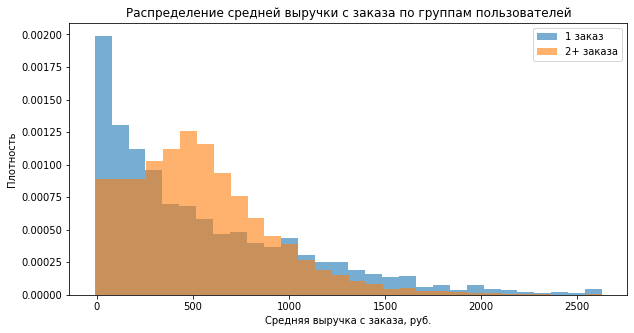

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    one_order['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='1 заказ'
)

plt.hist(
    returned_users['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='2+ заказа'
)

plt.title('Распределение средней выручки с заказа по группам пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

### Промежуточный вывод

Сравнение распределений средней выручки с заказа показало, что между пользователями с одним заказом и пользователями с 2 и более заказами есть различия.

У пользователей с одним заказом медианная средняя выручка составляет 378.03 руб., а основная масса значений сосредоточена примерно в диапазоне от 132 до 830 руб. При этом распределение более растянуто и содержит большую долю пользователей с низкой средней выручкой.

У вернувшихся пользователей медианная средняя выручка выше — 497.62 руб., а основная концентрация значений находится примерно в диапазоне от 274 до 739 руб. Их распределение выглядит более компактным и смещённым в сторону умеренно более высоких значений.

Хотя средние значения выручки в двух группах почти совпадают, форма распределений и медианы показывают, что вернувшиеся пользователи в среднем совершают заказы на несколько более высокие суммы. При этом экстремально высокая выручка сама по себе не выглядит признаком возврата: в группе пользователей с одним заказом разброс даже выше.

Таким образом, можно предположить, что вероятность возврата выше у пользователей с умеренно более высокой и стабильной средней выручкой с заказа, но связь между выручкой и повторными покупками не является линейной или очень сильной.

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответим на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [47]:
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
users_5_plus = user_profile[user_profile['total_orders'] >= 5]

print('Пользователей с 2–4 заказами:', len(users_2_4))
print('Пользователей с 5+ заказами:', len(users_5_plus))

Пользователей с 2–4 заказами: 7147
Пользователей с 5+ заказами: 6339


In [48]:
display(users_2_4['avg_revenue_rub'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
display(users_5_plus['avg_revenue_rub'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

count    7147.000000
mean      551.572388
std       420.197662
min        -5.380000
5%         40.820000
25%       218.425003
50%       471.269989
75%       798.549988
95%      1339.962012
max      2628.419922
Name: avg_revenue_rub, dtype: float64

count    6339.000000
mean      535.124329
std       294.615112
min         0.000000
5%         84.986000
25%       336.964996
50%       513.559998
75%       690.015015
95%      1052.081958
max      2299.870117
Name: avg_revenue_rub, dtype: float64

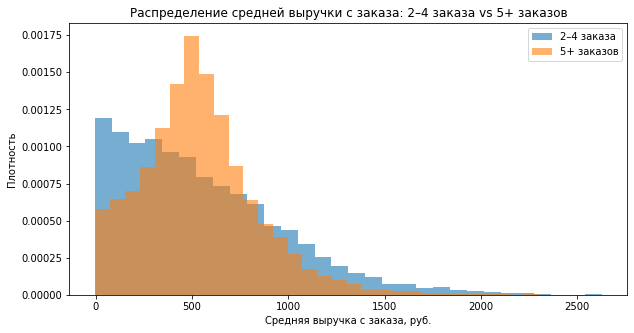

In [49]:
plt.figure(figsize=(10, 5))

plt.hist(
    users_2_4['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    users_5_plus['avg_revenue_rub'],
    bins=30,
    alpha=0.6,
    density=True,
    label='5+ заказов'
)

plt.title('Распределение средней выручки с заказа: 2–4 заказа vs 5+ заказов')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

### Промежуточный вывод

Сравнение пользователей с 2–4 заказами и пользователей с 5 и более заказами показывает, что между группами есть различия по средней выручке с заказа, но они не являются очень сильными.

У пользователей с 2–4 заказами медианная средняя выручка составляет 471.27 руб., а основная масса значений находится примерно в диапазоне от 218 до 799 руб. У пользователей с 5 и более заказами медиана выше — 513.56 руб., а основная концентрация значений находится примерно в диапазоне от 337 до 690 руб.

Таким образом, пользователи с 5 и более заказами в среднем совершают немного более дорогие заказы, если ориентироваться на медиану. Однако у пользователей с 2–4 заказами распределение более растянутое и содержит больше высоких значений, из-за чего их среднее значение выручки оказывается немного выше.

Следовательно, различия между группами есть, но они скорее связаны не с резким ростом средней выручки у самых активных пользователей, а с большей стабильностью и умеренно более высокой типичной выручкой в группе пользователей с 5 и более заказами.

---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

---

In [50]:
display(user_profile['avg_tickets_count'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

count    21854.000000
mean         2.743136
std          0.913090
min          1.000000
5%           1.000000
25%          2.000000
50%          2.750000
75%          3.080000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64

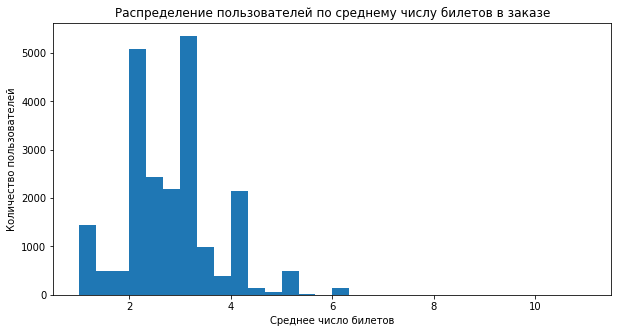

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(user_profile['avg_tickets_count'], bins=30)
plt.title('Распределение пользователей по среднему числу билетов в заказе')
plt.xlabel('Среднее число билетов')
plt.ylabel('Количество пользователей')
plt.show()

In [52]:
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets_count'],
    bins=[1, 2, 3, 5, np.inf],
    right=False,
    labels=['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов'],
    include_lowest=True
)

In [53]:
tickets_segments = (
    user_profile.groupby('tickets_segment')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_segments['users_share'] = (
    tickets_segments['users_count'] / tickets_segments['users_count'].sum() * 100
).round(2)

tickets_segments['return_rate'] = (tickets_segments['return_rate'] * 100).round(2)

display(tickets_segments)

,tickets_segment,users_count,return_rate,users_share
0,1–2 билета,2419,51.30,11.07
1,2–3 билета,9706,74.15,44.41
2,3–5 билетов,9068,54.30,41.49
3,5+ билетов,661,18.76,3.02


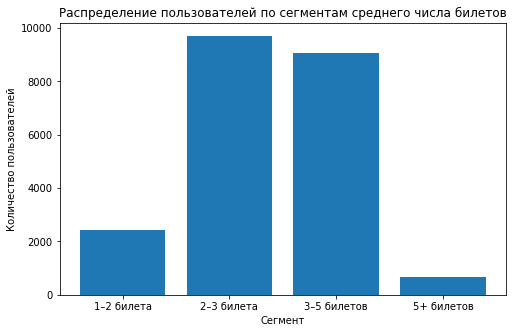

In [54]:
plt.figure(figsize=(8, 5))
plt.bar(tickets_segments['tickets_segment'], tickets_segments['users_count'])
plt.title('Распределение пользователей по сегментам среднего числа билетов')
plt.xlabel('Сегмент')
plt.ylabel('Количество пользователей')
plt.show()

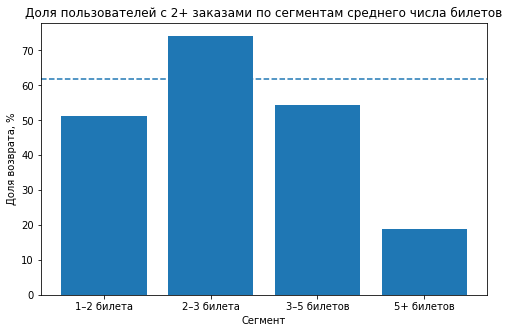

In [55]:
overall_return_rate = user_profile['is_two'].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(tickets_segments['tickets_segment'], tickets_segments['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по сегментам среднего числа билетов')
plt.xlabel('Сегмент')
plt.ylabel('Доля возврата, %')
plt.show()

### Промежуточный вывод

Распределение пользователей по среднему количеству билетов в заказе является неравномерным и явно сконцентрировано в диапазоне от 2 до 5 билетов. Среднее значение составляет 2.74 билета, медиана — 2.75 билета. Почти все пользователи сосредоточены в сегментах `2–3 билета` и `3–5 билетов`, которые вместе формируют около 85.9% выборки.

По сегментам среднее количество билетов распределено следующим образом:
- `1–2 билета` — 2419 пользователей (11.07%);
- `2–3 билета` — 9706 пользователей (44.41%);
- `3–5 билетов` — 9068 пользователей (41.49%);
- `5+ билетов` — 661 пользователь (3.02%).

Анализ доли повторных заказов показал выраженные различия между сегментами. Наиболее высокий уровень возврата наблюдается в сегменте `2–3 билета` — 74.15%, что существенно выше среднего по выборке (61.71%). Наоборот, сегмент `5+ билетов` показывает самую низкую долю повторных покупок — 18.76%, однако этот сегмент малочисленный, поэтому его результат следует интерпретировать осторожно.

Сегменты `1–2 билета` и `3–5 билетов` также демонстрируют долю повторных заказов ниже средней — 51.30% и 54.30% соответственно. Таким образом, наиболее устойчивым и успешным по удержанию выглядит сегмент пользователей, которые в среднем покупают от 2 до 3 билетов за заказ.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

---


In [56]:
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.dayofweek
weekday_map = {
    0: 'понедельник',
    1: 'вторник',
    2: 'среда',
    3: 'четверг',
    4: 'пятница',
    5: 'суббота',
    6: 'воскресенье'
}

user_profile['first_order_weekday'] = user_profile['first_order_weekday'].map(weekday_map)

In [57]:
weekday_returns = (
    user_profile.groupby('first_order_weekday')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_returns['return_rate'] = (weekday_returns['return_rate'] * 100).round(2)
weekday_returns['users_share'] = (
    weekday_returns['users_count'] / weekday_returns['users_count'].sum() * 100
).round(2)

In [58]:
weekday_order = [
    'понедельник',
    'вторник',
    'среда',
    'четверг',
    'пятница',
    'суббота',
    'воскресенье'
]

weekday_returns['first_order_weekday'] = pd.Categorical(
    weekday_returns['first_order_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_returns = weekday_returns.sort_values('first_order_weekday')

display(weekday_returns)

,first_order_weekday,users_count,return_rate,users_share
2,понедельник,2943,63.20,13.47
1,вторник,3189,62.06,14.59
4,среда,3072,62.37,14.06
6,четверг,3120,59.52,14.28
3,пятница,3261,59.86,14.92
5,суббота,3459,64.24,15.83
0,воскресенье,2810,60.50,12.86


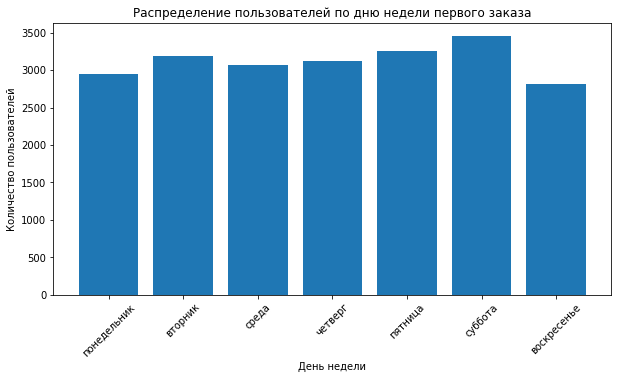

In [59]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_returns['first_order_weekday'], weekday_returns['users_count'])
plt.title('Распределение пользователей по дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

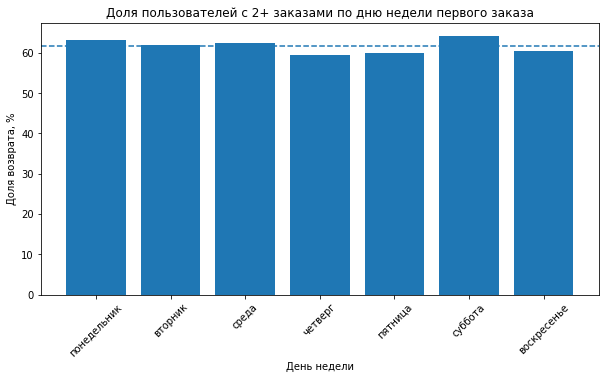

In [60]:
overall_return_rate = user_profile['is_two'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(weekday_returns['first_order_weekday'], weekday_returns['return_rate'])
plt.axhline(overall_return_rate, linestyle='--')
plt.title('Доля пользователей с 2+ заказами по дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Доля возврата, %')
plt.xticks(rotation=45)
plt.show()

### Промежуточный вывод

Распределение пользователей по дню недели первого заказа выглядит достаточно равномерным: доля пользователей по отдельным дням колеблется от 12.86% до 15.83%. Это означает, что выраженной концентрации первого спроса в одном конкретном дне недели нет, хотя немного больше пользователей совершают первый заказ в пятницу и субботу.

Доля пользователей, совершивших 2 и более заказа, различается по дням недели, но не слишком сильно. Наиболее высокий возврат наблюдается у пользователей, чей первый заказ был сделан в субботу — 64.24%. Также выше средней по выборке доля возврата у пользователей, пришедших в понедельник (63.20%), вторник (62.06%) и среду (62.37%). Ниже средней доля возврата в четверг (59.52%), пятницу (59.86%) и воскресенье (60.50%).

Таким образом, день недели первой покупки может быть слабо связан с вероятностью возврата пользователя, однако различия между днями относительно невелики. Следовательно, этот признак вряд ли является одним из ключевых факторов удержания, хотя его можно учитывать как дополнительную характеристику пользовательского поведения.

---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитаем среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа.

---


In [61]:
users_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
users_5_plus = user_profile[user_profile['total_orders'] >= 5]

print('Пользователей с 2–4 заказами:', len(users_2_4))
print('Пользователей с 5+ заказами:', len(users_5_plus))

Пользователей с 2–4 заказами: 7147
Пользователей с 5+ заказами: 6339


In [62]:
display(users_2_4['avg_days_between'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
display(users_5_plus['avg_days_between'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

count    7147.000000
mean       21.317881
std        28.480066
min         0.000000
5%          0.000000
25%         0.000000
50%         9.000000
75%        34.000000
95%        84.000000
max       148.000000
Name: avg_days_between, dtype: float64

count    6339.000000
mean        9.579575
std         7.858812
min         0.000000
5%          0.120000
25%         3.420000
50%         7.790000
75%        13.790000
95%        25.750000
max        37.500000
Name: avg_days_between, dtype: float64

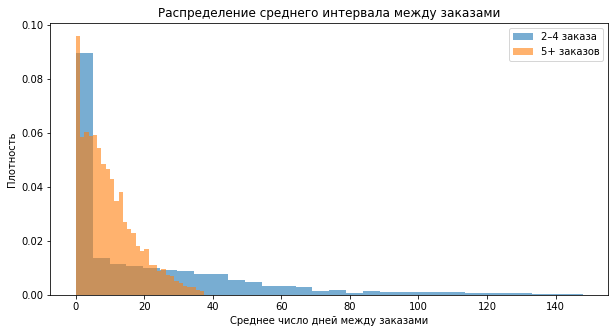

In [63]:
plt.figure(figsize=(10, 5))

plt.hist(
    users_2_4['avg_days_between'].dropna(),
    bins=30,
    alpha=0.6,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    users_5_plus['avg_days_between'].dropna(),
    bins=30,
    alpha=0.6,
    density=True,
    label='5+ заказов'
)

plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Среднее число дней между заказами')
plt.ylabel('Плотность')
plt.legend()
plt.show()

### Промежуточный вывод

Сравнение среднего интервала между заказами у пользователей с 2–4 заказами и пользователей с 5 и более заказами показывает выраженную связь между частотой покупок и уровнем удержания.

У пользователей с 2–4 заказами средний интервал между покупками составляет 21.32 дня, медианный — 9 дней. Распределение интервала в этой группе сильно растянуто: 75% пользователей имеют средний интервал до 34 дней, а 95% — до 84 дней.

У пользователей с 5 и более заказами средний интервал значительно меньше — 9.58 дня, медианный — 7.79 дня. Их распределение заметно более компактное: 75% пользователей имеют средний интервал до 13.79 дня, а 95% — до 25.75 дня.

Таким образом, более активные пользователи возвращаются на платформу заметно быстрее и совершают покупки с меньшими промежутками между заказами. Это позволяет сделать вывод, что короткий средний интервал между покупками связан с более высоким удержанием пользователя и может рассматриваться как один из важных признаков вовлечённости.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведем корреляционный анализ:
- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). 

---

In [64]:
corr_data = user_profile[
    [
        'total_orders',
        'first_device_type',
        'first_region_name',
        'first_service_name',
        'first_event_type_main',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between',
        'is_two',
        'is_five'
    ]
].copy()

In [65]:
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
phik_matrix = corr_data.phik_matrix(interval_cols=interval_cols)
display(phik_matrix['total_orders'].sort_values(ascending=False))

total_orders             1.000000
first_region_name        0.127203
first_service_name       0.101909
is_five                  0.077858
is_two                   0.034736
first_device_type        0.000000
first_event_type_main    0.000000
avg_revenue_rub          0.000000
avg_tickets_count        0.000000
avg_days_between         0.000000
Name: total_orders, dtype: float64

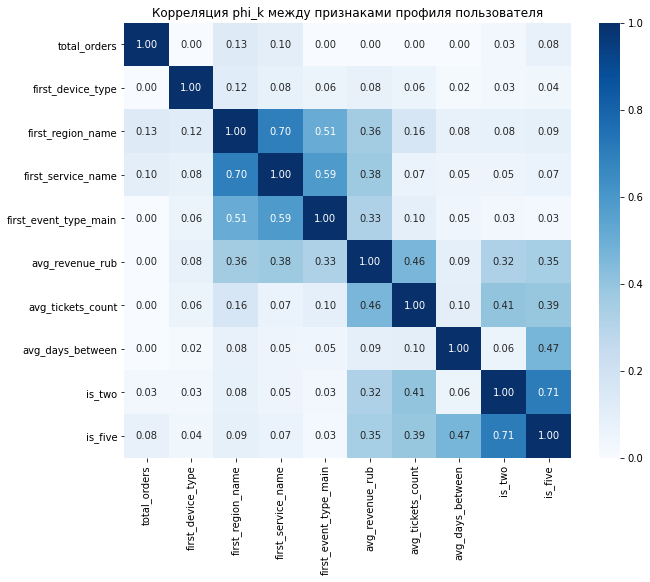

In [66]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title('Корреляция phi_k между признаками профиля пользователя')
plt.show()

Корреляция слабая. Поделим на сегменты по заказам:

In [67]:
def orders_group(x):
    if x == 1:
        return '1 заказ'
    elif 2 <= x <= 4:
        return '2–4 заказа'
    else:
        return '5+ заказов'

corr_data['orders_group'] = corr_data['total_orders'].apply(orders_group)

In [68]:
corr_data_segmented = corr_data.drop(columns='total_orders').copy()
interval_cols_segmented = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
phik_matrix_segmented = corr_data_segmented.phik_matrix(
    interval_cols=interval_cols_segmented
)
display(phik_matrix_segmented['orders_group'].sort_values(ascending=False))

is_two                   1.000000
is_five                  1.000000
orders_group             1.000000
avg_days_between         0.393448
avg_tickets_count        0.390477
avg_revenue_rub          0.334764
first_region_name        0.125589
first_service_name       0.085467
first_event_type_main    0.041205
first_device_type        0.016259
Name: orders_group, dtype: float64

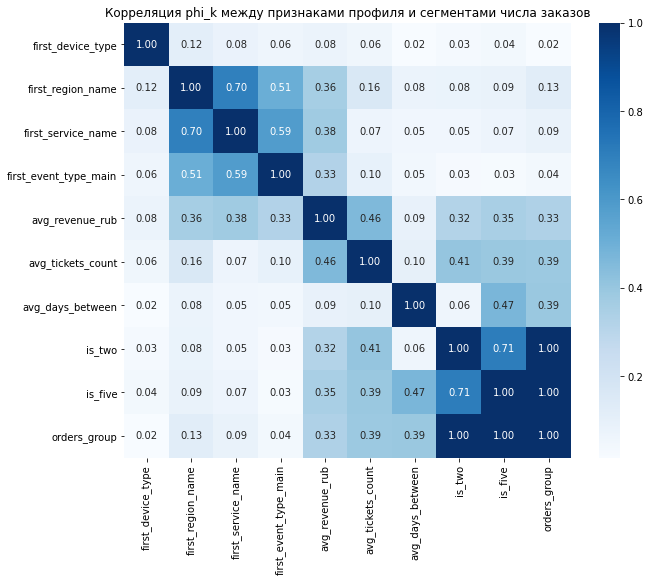

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix_segmented, annot=True, fmt='.2f', cmap='Blues')
plt.title('Корреляция phi_k между признаками профиля и сегментами числа заказов')
plt.show()

Первичный расчёт коэффициента phi_k между признаками профиля пользователя и точным числом заказов (total_orders) показал в основном очень слабые связи. Это связано с тем, что распределение количества заказов в выборке сильно скошено: у большинства пользователей заказов немного, но присутствует небольшая группа крайне активных пользователей с очень большими значениями. Поэтому для более корректного анализа число заказов было дополнительно преобразовано в сегменты: 1 заказ, 2–4 заказа, 5+ заказов.

Повторный корреляционный анализ по сегментам показал, что наиболее связаны с количеством заказов поведенческие признаки пользователя. Самые высокие значения phi_k получены для среднего количества билетов в заказе (avg_tickets_count, около 0.39), среднего интервала между заказами (avg_days_between, около 0.39) и средней выручки с заказа (avg_revenue_rub, около 0.33). Это означает, что количество заказов в большей степени связано с текущим покупательским поведением пользователя, чем с характеристиками его первого заказа.

Среди признаков первого заказа наиболее заметную, но всё же слабую связь показывают регион первого заказа (first_region_name, около 0.13) и билетный оператор (first_service_name, около 0.09). Связь типа первого мероприятия (first_event_type_main) и устройства первого заказа (first_device_type) с количеством заказов практически отсутствует.

Таким образом, наиболее информативными для понимания уровня активности пользователя оказались не признаки первой покупки, а агрегированные характеристики его поведения: частота покупок, среднее количество билетов и средняя выручка.

### 5. Общий вывод и рекомендации


В ходе анализа были изучены данные о заказах пользователей Яндекс Афиши. Данные были очищены: выручка приведена к рублям, обработаны пропуски, удалены выбросы (около 1% наблюдений). В результате сформирован профиль 21 854 пользователей.

Распределение пользователей по числу заказов неравномерное: медиана — 2 заказа, при этом есть небольшая группа очень активных пользователей. Доля пользователей с 2+ заказами — 61.7%, с 5+ — 29.0%. Средняя выручка с заказа — 544 руб.

Анализ первого заказа показал, что пользователи приходят в основном через концерты, мобильные устройства, крупные регионы и крупных билетных операторов. Однако характеристики первого заказа слабо связаны с возвратом: небольшое преимущество имеют пользователи, пришедшие через концерты и театр, а также с desktop, но различия невелики.

Связь с повторными покупками сильнее проявляется в поведенческих характеристиках. Пользователи с 2–3 билетами в заказе возвращаются чаще всего (~74%), тогда как сегмент 5+ билетов показывает низкий возврат. Средняя выручка у вернувшихся пользователей немного выше, но различия умеренные.

Из временных факторов день недели первого заказа почти не влияет на возврат. При этом средний интервал между заказами — ключевой фактор: чем он меньше, тем выше активность пользователя. Пользователи с 5+ заказами совершают покупки значительно чаще.

Корреляционный анализ подтвердил, что наиболее связаны с количеством заказов:

среднее число билетов,
средний интервал между покупками,
средняя выручка.

Признаки первого заказа (тип события, устройство, регион) имеют слабую связь с числом заказов.

### Рекомендации

Основное внимание стоит уделить не столько источнику первого заказа, сколько поведению пользователя после него.

В первую очередь рекомендуется:

фокусироваться на пользователях с 2–3 билетами в заказе и небольшими интервалами между покупками — это наиболее перспективный сегмент;
стимулировать повторные покупки в первые дни после заказа (сокращать интервал);
усиливать удержание мобильных пользователей (основной канал привлечения);
отдельно прорабатывать слабые сегменты (спорт, 1–2 билета) через персональные предложения и напоминания.

Для дальнейшей аналитики и моделей удержания ключевыми признаками следует считать поведенческие метрики, а характеристики первого заказа использовать как дополнительные.